In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import cobra
from scipy.stats import spearmanr, pearsonr
from matplotlib import font_manager
import os
import sys
sys.path.append('../')
from modelfunctions import *

# use Arial
try: 
    font_path = '/home/emil/.fonts/ARIAL.TTF'  # Your font path goes here
    font_manager.fontManager.addfont(font_path)
    prop = font_manager.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = prop.get_name()
except:
    print('Arial font not found, using default')

wd = os.path.abspath(os.getcwd()).removesuffix('Code/validation')
figdir = wd + 'Figures/'

cols_opt_order = [(r/0xff, g/0xff, b/0xff) for r,g,b in [(0x67, 0x19, 0x70),
 (0xee, 0x96, 0x4b), (0x0, 0x6d, 0x6f), (0xb6, 0xd0, 0x94), (0xe5, 0x62, 0x5e),
 (0xff, 0xbf, 0xa0), (0x66, 0x0, 0x0), (0xab, 0x81, 0xcd), (0x29, 0x70, 0x45),
 (0xba, 0xde, 0xfc)]]
colors = cols_opt_order

In [ ]:
# Functions
# find_scaling finds a scaling factor between the ecPcm and the ecWholeCellModel so that
#   the fluxes through transporters are the same as in the conventional version
#   jumping break is supposed to prevent the algorithm from spiraling out of control
#       it makes it so only 1/jumping_break of the difference between scaling factors of two iterations is applied
def find_scaling(ecm, noEcm, tr_ids, iterate = False, tol = 0.05, apply = False, x0 = None, it_limit = 10, jumping_break = 1):
    ori_fac = get_rid(ecm, 'prot_pool_chl').metabolites[get_mid(ecm, 'prot_pool[h]')]
    print('Previous scaling factor:', -ori_fac)

    if x0 is not None:
        get_rid(ecm, 'prot_pool_chl').add_metabolites({get_mid(ecm, 'prot_pool[h]') : - ori_fac - x0})
        ori_fac = get_rid(ecm, 'prot_pool_chl').metabolites[get_mid(ecm, 'prot_pool[h]')]
        print('New, provided scaling factor:', -ori_fac)


    noEcSol = cobra.flux_analysis.pfba(noEcm)
    ecSol = cobra.flux_analysis.pfba(ecm)
    transp_ratio = ecSol.fluxes.loc[tr_ids].sum() / noEcSol.fluxes.loc[tr_ids].sum()
    print('With this factor, the mean ratio of transporter fluxes of ec vs non-ec is', round(transp_ratio, 5))

    new_fac = -ori_fac
    it = 0 
    sampled_points = {new_fac: transp_ratio}
    while abs(transp_ratio - 1) > tol:
        it += 1
        if it > it_limit:
            print('Reached iteration limit. Stopping.')
            best_diff = min([abs(1-x) for x in sampled_points.values()])
            for fac in sampled_points:
                if abs(1-sampled_points[fac]) == best_diff:
                    new_fac = fac
                    best_ratio = sampled_points[fac]
                    break
            print(f'Using {round(new_fac, 5)} as factor, the best fit so far with a ratio of', round(best_ratio, 5))

            # apply
            if apply:
                prev_fac = get_rid(ecm, 'prot_pool_chl').metabolites[get_mid(ecm, 'prot_pool[h]')]
                get_rid(ecm, 'prot_pool_chl').add_metabolites({get_mid(ecm, 'prot_pool[h]') : - prev_fac - new_fac})
            break

        # change protein scaling factor
        new_fac = new_fac + (new_fac/transp_ratio - new_fac) / jumping_break
        prev_fac = get_rid(ecm, 'prot_pool_chl').metabolites[get_mid(ecm, 'prot_pool[h]')]
        get_rid(ecm, 'prot_pool_chl').add_metabolites({get_mid(ecm, 'prot_pool[h]') : - prev_fac - new_fac})
        # calculate new ratio
        ecSol = cobra.flux_analysis.pfba(ecm)
        transp_ratio = ecSol.fluxes.loc[tr_ids].sum() / noEcSol.fluxes.loc[tr_ids].sum()
        print(f'With {round(new_fac, 5)} as factor, the mean ratio of transporter fluxes of ec vs non-ec is', round(transp_ratio, 5))
        sampled_points[new_fac] = transp_ratio
        if not iterate:
            break

    if not apply:
        prev_fac = get_rid(ecm, 'prot_pool_chl').metabolites[get_mid(ecm, 'prot_pool[h]')]
        get_rid(ecm, 'prot_pool_chl').add_metabolites({get_mid(ecm, 'prot_pool[h]') : - prev_fac + ori_fac})

    return new_fac

# gather data on protein usage: In AraCore, these reactions are named draw_prot
def gather_prot_usage(sol):
    df = sol.fluxes.loc[[rid for rid in sol.fluxes.index if rid.startswith('usage_prot_')]].reset_index()
    df.columns = ['rxns', 'usage']
    df['usage'] = -df['usage']
    df['prot'] = df['rxns'].apply(lambda x: x.removeprefix('usage_prot_').removesuffix('_r'))
    df = df.sort_values('usage', ascending=False)

    return df[['prot', 'usage']]

def prot_distr_plot(final, savename, left = ['Aldolase', 'SBPase', 'R5P epimerase', 'Ru5P kinase'],
                    bottom = ['PGA kinase', 'Rubisco'], no_box = [], top = [], center = [], super_bottom = [],
                    center_left = [], figsize = (4.5, 4), 
                    cix = 2, fontsize = 12):
    plt.figure(figsize=figsize)

    # diagonal line
    plt.plot([0.0001, 60], [0.0001, 60], '--', color='grey')

    # markers
    pred_plot_values = final['prediction'].apply(lambda x: max(0.0001, x))
    plt.plot(final['experimental'], pred_plot_values, 'o', color=colors[cix], zorder=100)

    # texts
    text_props = dict(boxstyle='round', facecolor='white', alpha=0.8, linewidth=0, pad = 0.05)
    for enz in final.index:
        x = final.loc[enz, 'experimental'] * 0.8
        ha = 'right'
        va = 'center'
        if enz in left:
            x = final.loc[enz, 'experimental'] * 1.25
            ha = 'left'
        if enz in bottom:
            va = 'bottom'
        if enz in center:
            ha = 'center'
        if enz in top:
            va = 'top'
        y = pred_plot_values.loc[enz]
        if enz in super_bottom:
            y = y + 0.2
        if enz in center_left:
            x = x - .4
            y = y - 0.005
        plt.text(x, y, enz, ha=ha, va=va, bbox = None if enz in no_box else text_props, zorder = 1000, fontsize = fontsize)

    # general properties
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Experimental protein usage (%)', fontdict={'fontsize': fontsize})
    plt.ylabel('Predicted protein usage (%)', fontdict={'fontsize': fontsize})

    # end
    plt.savefig(figdir + savename, dpi=300, transparent=True, bbox_inches = "tight")
    plt.show()

In [3]:
# data from Evans et al 89:
expData = {'Rubisco': 20.4,
           'PGA kinase': 0.36,
           'GAPDH': 0.76,
           'Triose P Isom.': 0.53,
           #'F1,6 aldolase': 0.44 + 0.78, # the aldolase is the same enzyme
           'FBPase': 0.16,
           'Transketolase': 0.23,
           'Aldolase': 0.44 + 0.78, # the F1,6 aldolase is the same enzyme
           'SBPase': 2.32,
           'R5P epimerase': 0.08,
           'R5P isomerase': 0.09,
           'Ru5P kinase': 0.51}

# associate these names to uniprot IDs
name2upe = {'Rubisco': ['P10795', 'O03042', 'P10796', 'P10797', 'P10798'], # RBC_h and RBO_h
            'PGA kinase': ['P50318', 'Q9LD57', 'Q9SAJ4'],  # R01512
            'GAPDH': ['Q9LPW0', 'P25856', 'P25857', 'Q9SAJ6', 'Q5E924'], # R01063 and R01061
            'Triose P Isom.': ['Q9SKP6'], # R01015
            # maybe they meant R01829 for aldolase and R01068 for f16 aldolase?
            # they are catalyzed by the same proteins
            #'F1,6 aldolase': ['Q9SJU4', 'Q9ZU52', 'Q944G9'],
            'Aldolase': ['Q9SJU4', 'Q9ZU52', 'Q944G9'],
            'FBPase': ['P25851'],  # R00762
            'Transketolase': ['F4IW47', 'Q8RWV0'], # R06861 + R06863_REV; also R01067
            'SBPase': ['P46283'], # R01845
            'R5P epimerase': ['Q9SAU2'], # R01529
            'R5P isomerase': ['Q9S726', 'Q9FI13'], # R01056
            'Ru5P kinase': ['P25697']} # Ru5PK_h

In [34]:
# use the tuned version of Ath ecPcm
ecm = cobra.io.read_sbml_model(wd + 'Data/pcm/pluggedIntoAraCore/AraCore.ecpcm.tuned.xml')
noEcm = cobra.io.read_sbml_model(wd + 'Data/pcm/pluggedIntoAraCore/AraCore.Arabidopsis_thaliana.pcm.xml')

# collect chloroplast-cytosol transport reactions
transps = set()
for r in noEcm.reactions:
    curr_comps = {m.compartment for m in r.metabolites}
    if 'h' in curr_comps and 'c' in curr_comps and not r.id.startswith('Bio'):
        transps.add(r)
tr_ids = [r.id for r in transps]

scal_fac = find_scaling(ecm, noEcm, tr_ids, iterate = True, tol = 0.01, apply = True, x0=6260,
                        jumping_break = 100, it_limit = 30)

Loading SBML model without fbc:strict="true"


Previous scaling factor: 1.0
New, provided scaling factor: 6260.0
With this factor, the mean ratio of transporter fluxes of ec vs non-ec is 1.09469
With 6254.58535 as factor, the mean ratio of transporter fluxes of ec vs non-ec is 1.00713


In [35]:
# gather CBC protein usage predictions
total_prot_bound = get_rid(ecm, 'prot_pool_exchange').upper_bound
scal_fac = -get_rid(ecm, 'prot_pool_chl').metabolites[get_mid(ecm, 'prot_pool[h]')]
ecSol = cobra.flux_analysis.pfba(ecm)
df = gather_prot_usage(ecSol)
preds = {}
for enz in name2upe:
    preds[enz] = df.loc[df['prot'].isin(name2upe[enz]), 'usage'].sum() / scal_fac / total_prot_bound * 100 # calculate as percentage of total protein 

final = pd.DataFrame({'experimental': expData, 'prediction': preds})
final.to_csv(wd + 'Data/analysis/protDistr_final.csv')

sc, sp = spearmanr(final['experimental'], final['prediction'], alternative='greater')
pc, pp = pearsonr(final['experimental'], final['prediction'], alternative='greater')
def p_str(p):
    if p <1e-3:
        return "{:.3e}".format(p)
    else:
        return round(p, 4)
    
print(f'The protein distribution predictions have a Spearman correlation of {round(sc, 2)} (p={p_str(sp)}) with the experimental results.')
print(f'The protein distribution predictions have a Pearson correlation of {round(pc, 2)} (p={p_str(pp)}) with the experimental results.')

print('After outlier removal:')
outl_rem = final.loc[final['prediction'] != 0]
sc, sp = spearmanr(outl_rem['experimental'], outl_rem['prediction'], alternative='greater')
pc, pp = pearsonr(outl_rem['experimental'], outl_rem['prediction'], alternative='greater')
def p_str(p):
    if p <1e-3:
        return "{:.3e}".format(p)
    else:
        return round(p, 4)

print(f'The protein distribution predictions have a Spearman correlation of {round(sc, 2)} (p={p_str(sp)}) with the experimental results.')
print(f'The protein distribution predictions have a Pearson correlation of {round(pc, 2)} (p={p_str(pp)}) with the experimental results.')

The protein distribution predictions have a Spearman correlation of 0.74 (p=0.0049) with the experimental results.
The protein distribution predictions have a Pearson correlation of 0.99 (p=2.255e-10) with the experimental results.
After outlier removal:
The protein distribution predictions have a Spearman correlation of 0.68 (p=0.0144) with the experimental results.
The protein distribution predictions have a Pearson correlation of 0.99 (p=1.929e-09) with the experimental results.


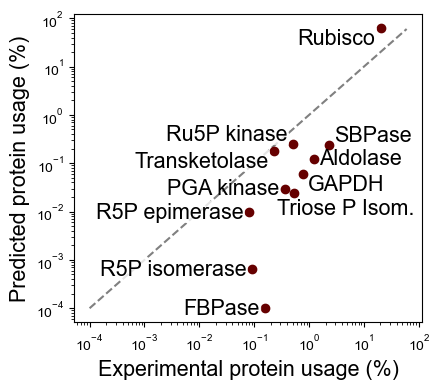

,experimental,prediction
Rubisco,20.40,62.215780
PGA kinase,0.36,0.029941
GAPDH,0.76,0.061038
Triose P Isom.,0.53,0.023942
FBPase,0.16,0.000000
Transketolase,0.23,0.182647
Aldolase,1.22,0.125343
SBPase,2.32,0.239240
R5P epimerase,0.08,0.009845
R5P isomerase,0.09,0.000652


In [36]:
prot_distr_plot(final, 'protDistr.tuned.png', left = ['Triose P Isom.', 'SBPase', 'Aldolase', 'GAPDH'],
                top = ['Triose P Isom.', 'Rubisco', 'Transketolase', 'GAPDH'], bottom = ['SBPase', 'Ru5P kinase'],
                no_box = ['Triose P Isom.', 'Aldolase', 'PGA kinase', 'GAPDH', 'SBPase'],
                center_left = ['Triose P Isom.'], cix = 6, fontsize = 15.5)
final